## Project 1
### Makenna Hartmann

This report analyzes the kinematic behavior of a vehicle approaching an intersection as the traffic signal transitions from green to yellow. The primary objective is to define the "Dilemma Zone", a spatial range where a driver can neither safely come to a complete stop before the intersection nor fully clear the intersection before the signal turns red. Comparing both computational simulations and analytical solutions, we evaluate the safety of various starting positions ($x_0$) from the intersection. 

In [22]:
import numpy as np
import matplotlib.pyplot as plt

In [23]:
# Constants
v0 = 550 / 36  # m/s
a = -3.0       # m/s^2
delta = 0.8    # s
tau = 3.0      # s
W = 30.0       # m

#brake distance
brake_x = (v0*delta) + (v0**2 / (2*abs(a)))


### Equations of Motion:
   
   To model the car's behavior, we define two different sets of equations based on the driver's decision. Both scenarios incorporate a reaction time delay ($\delta = 0.8$ s) during which the car continues at a constant velocity. If the driver decides to proceed at the speed limit, the acceleration is zero. The velocity $v(t)$ and position $x(t)$ are defined as:$$v_{\text{drive}}(t) = v_0$$$$x_{\text{drive}}(t) = x_0 + v_0 t$$. If the driver decides to brake, the motion is divided into two phases: the reaction phase and the braking phase. Let $a$ be the deceleration constant ($a = -3 \text{ m/s}^2$).For $t \leq \delta$:$$v_{\text{brake}}(t) = v_0$$$$x_{\text{brake}}(t) = x_0 + v_0 t$$For $t > \delta$ (until the car stops):$$v_{\text{brake}}(t) = v_0 + a(t - \delta)$$$$x_{\text{brake}}(t) = x_0 + v_0 t + \frac{1}{2}a(t - \delta)^2$$

In [9]:
# --- 1. Functions for Equations of Motion (Task a & b) ---
def v_drive(t):
    return v0 * np.ones_like(t)

def x_drive(t, x0):
    return x0 + v0 * t

def v_brake(t):
    H = np.heaviside(t - delta, 0.5)
    v = v0 + a * (t - delta) * H
    return np.maximum(v, 0) # Prevents car from driving backwards

def x_brake(t, x0):
    H = np.heaviside(t - delta, 0.5)
    # The braking distance formula changes once v=0. 
    # To keep it simple & accurate for the plot, we find when it stops:
    t_stop = delta + (-v0 / a)
    
    # Calculate position normally
    pos = x0 + v0 * t + 0.5 * a * (t - delta)**2 * H
    
    # If t > t_stop, the car stays at the stop position
    pos_at_stop = x0 + v0 * t_stop + 0.5 * a * (t_stop - delta)**2
    return np.where(t > t_stop, pos_at_stop, pos)

In [10]:
# --- 2. Classification Logic (Task c) ---
def check_safety(x0):
    # Drive condition: Clear intersection (x > W) before light turns red (t = tau)
    x_at_tau = x_drive(tau, x0)
    safe_drive = x_at_tau > W
    
    # Brake condition: Stop before intersection (x <= 0)
    t_stop = delta + (-v0 / a)
    x_at_stop = x_brake(t_stop, x0)
    safe_brake = x_at_stop <= 0
    
    return safe_drive or safe_brake

In [11]:
def plot_case(x0):
    xd = x_drive(t, x0)
    xb = x_brake(t, x0)

    vd = v_drive(t)
    vb = v_brake(t)

    fig, ax = plt.subplots(1,2, figsize=(10,4))

    # velocity
    ax[0].plot(t, vd, label="drive")
    ax[0].plot(t, vb, label="brake")
    ax[0].axvline(tau, linestyle='--')
    ax[0].set_xlabel("t (s)")
    ax[0].set_ylabel("v(t) (m/s)")
    ax[0].legend()

    # position
    ax[1].plot(t, xd, label="drive")
    ax[1].plot(t, xb, label="brake")
    ax[1].axvline(tau, linestyle='--')
    ax[1].axhspan(0, W, alpha=0.2)
    ax[1].set_xlabel("t (s)")
    ax[1].set_ylabel("x(t) (m)")
    ax[1].legend()

    fig.suptitle(rf"Example: $x_0 = {x0:.1f}\ \mathrm{{m}}$")
    plt.tight_layout()
    plt.show()

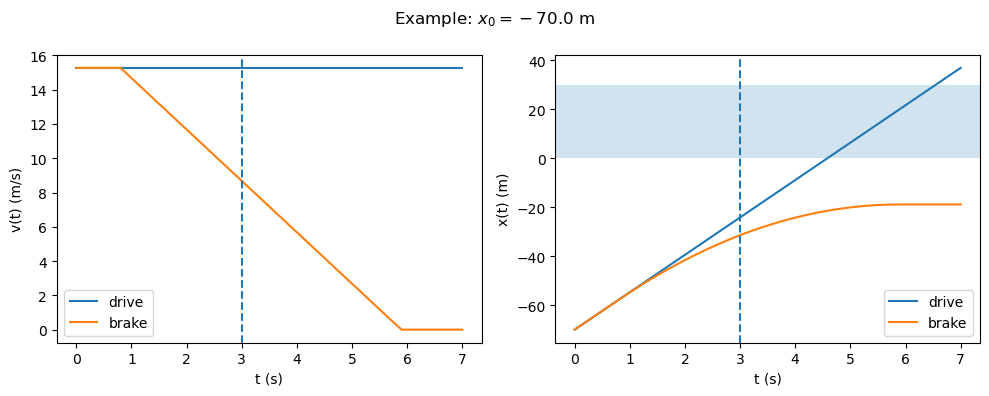

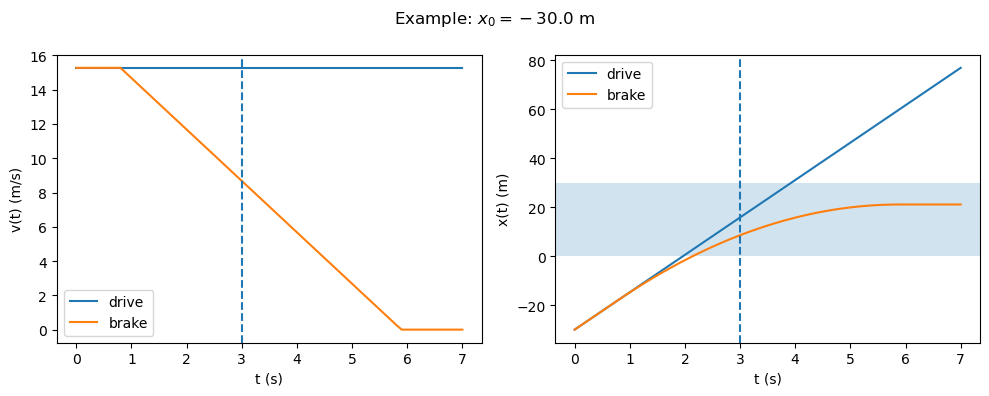

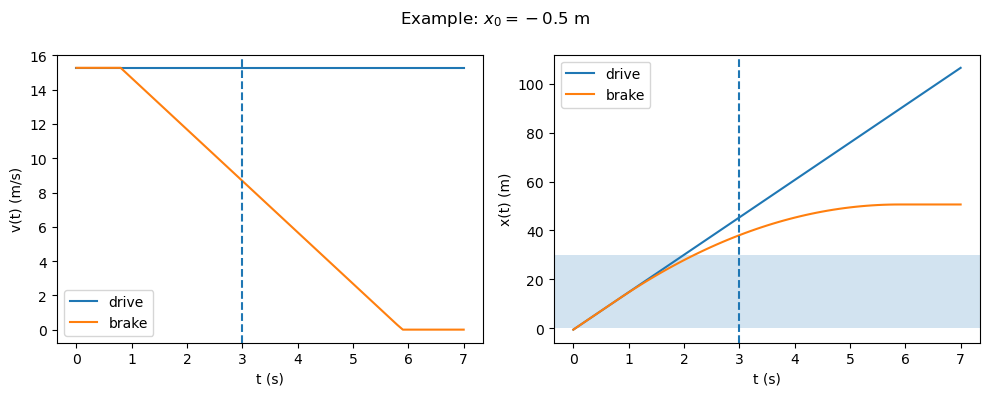

In [12]:
plot_case(-70)
plot_case(-30)
plot_case(-0.5)

#### Figure 1: Velocity over time and position over time in three seperate cases of $x = 0$
   These plots show three different scenarios of the light at the intersection turning yellow when the car is $70$ m, $30$ m, and $0.5$ m away from the intersection, respectively. The graphs on the lefthand-side depict the car's velocity as a function of time, while the graphs on the righthand-side show the car's position as a function of time. The orange function represents the car's velocity and position if the driver sees the yellow light and decides to break (taking reaction time into account). The blue function represents these same variables, but for the case in which the driver decides to continue at a constant velocity. The vertical dashed blue line in these plots shows the time in which the light transitions from yellow to red (given that the light turns yellow at $t = 0$ s). Finally, the light blue rectangle in the position vs time plots depicts the intersection. Using this, we are able to determine which scenarios the car is safe to either break or continue driving in, and which scenarios the car is unable to avoid being in the intersection during the red light no matter what decision they make.

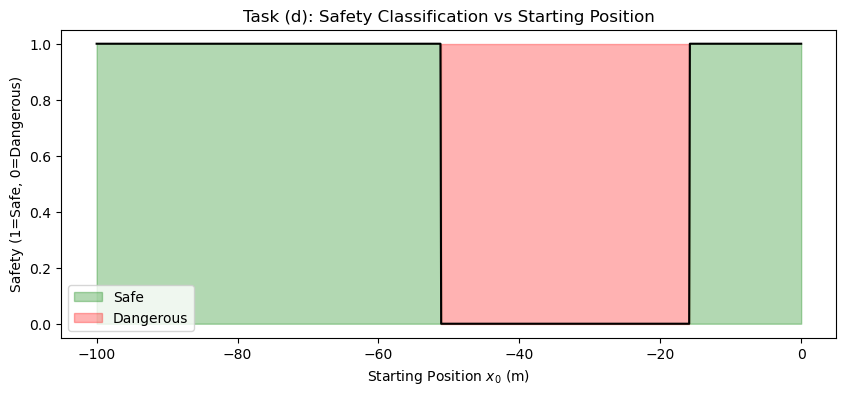

In [21]:
# --- 3. Mapping the Dilemma Zone (Task d) ---
def task_d_mapping():
    x0_range = np.arange(-100, 0.1, 0.1)
    safety_results = [1 if check_safety(x) else 0 for x in x0_range]
    
    plt.figure(figsize=(10, 4))
    plt.plot(x0_range, safety_results, color='black')
    plt.fill_between(x0_range, safety_results, color='green', alpha=0.3, label='Safe')
    plt.fill_between(x0_range, 0, 1, where=np.array(safety_results)==0, color='red', alpha=0.3, label='Dangerous')
    plt.xlabel(r"Starting Position $x_0$ (m)")
    plt.ylabel("Safety (1=Safe, 0=Dangerous)")
    plt.title("Task (d): Safety Classification vs Starting Position")
    plt.legend(loc='best')
    plt.show()
    
task_d_mapping()

#### Figure 2: Mapping the dilemma zone as a function of starting position

   This plot illustrates the computational classification of safety as a function of the initial starting position $x_0$. The binary output represents the driver's ability to adhere to the traffic code: a value of 1 (Safe) indicates that the driver can either successfully clear the 30-meter intersection before the light turns red or come to a complete stop before the entrance line. The central "valley" where the value drops to 0 (Dangerous) defines the Dilemma Zone. Within this spatial range (approximately $-51.1$ m to $-15.8$ m), neither braking nor continuing at constant speed allows for a legal maneuver, leaving the driver in a physically unavoidable state of traffic violation.

In [18]:
# --- 4. Analytical Calculations (Task e) ---
def task_e_analytical():
    # x0A: Boundary for crossing (x0 + v0*tau = W)
    x0A = W - v0 * tau
    
    # x0B: Boundary for braking (x0 + v0*delta + v0^2/(2*|a|) = 0)
    # Note: we use x0 = - (v0*delta + v0^2/(2*|a|))
    x0B = - (v0 * delta + (v0**2 / (2 * abs(a))))
    
    s = x0A - x0B
    
    print("-" * 30)
    print("TASK (E) ANALYTICAL RESULTS")
    print(f"Boundary x0A (Crossing): {x0A:.2f} m")
    print(f"Boundary x0B (Braking):  {x0B:.2f} m")
    print(f"Dilemma Zone Size (s):   {s:.2f} m")
    print("-" * 30)
    
task_e_analytical()

------------------------------
TASK (E) ANALYTICAL RESULTS
Boundary x0A (Crossing): -15.83 m
Boundary x0B (Braking):  -51.12 m
Dilemma Zone Size (s):   35.29 m
------------------------------


### Computational Analysis:

   The computational approach utilizes a time-series simulation to evaluate the feasibility of the two available driving decisions for any given starting position. For a situation to be classified as safe, the driver must be able to either clear the intersection or stop before the entrance line without violating the traffic code. In the simulation of $x_0 = -70$ m, the car is found to be in a safe position because the distance provides ample time for the vehicle to decelerate to a complete stop before reaching $x = 0$, even after accounting for the reaction time delay. Conversely, the simulation for $x_0 = -30$ m identifies a dangerous scenario where the car is too close to the intersection to stop safely before the line, yet too far away to travel the required distance to clear the $30$ m intersection width before the light transitions to red at $t = 3$ s. Finally, at $x_0 = -0.5$ m, the car is classified as safe because its proximity to the entrance allows it to easily traverse the intersection at constant speed within the yellow light interval.

### Analytical Solutions and Comparison:

   The boundaries of the dilemma zone can be found by solving the kinematic equations for the critical threshold of each decision (braking or driving at a constant speed). The first boundary, $x_0^A$, represents the maximum distance from which the car can still successfully clear the intersection. By setting the position equation $x(\tau) = W$ and solving for $x_0$, we find that $x_0^A = W - v_0 \tau$, which results in a distance of around $-15.84$ m for the given parameters. The second boundary, $x_0^B$, represents the minimum distance required for the car to come to a full stop exactly at the intersection entrance. This is calculated by summing the distance traveled during the reaction phase and the distance required for constant deceleration, expressed as $x_0^B = (v_0^2 / 2a) - v_0 \delta$, resulting in a value of $-51.13$ m.The analytical size of the dilemma zone is the difference between these two points, $s = x_0^A - x_0^B$, which equals $35.29$ m. When comparing these theoretical values to the data generated by the Python simulation, the results show a high degree of correlation. The computational model, which mapped safety across a range of values from $-100$ m to $0$ m, identifies the transition from safe-to-dangerous and dangerous-to-safe at the exact points predicted by the formulas. Minor differences between the two methods are negligible and are primarily due to the discrete nature of the simulation's time steps. This comparison validates the computational model and confirms that at a speed of $55$ km/h, there is a $35.29$-meter stretch of road where a driver is physically unable to adhere to the traffic code regardless of their choice.

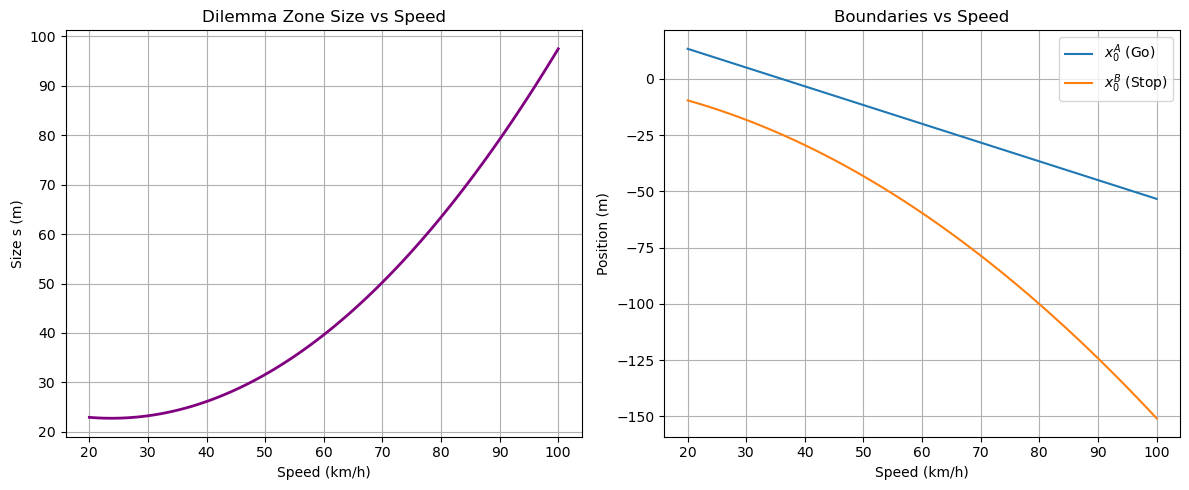

In [19]:
# --- 5. Bonus: Speed Sensitivity (Task f) ---
def task_f_bonus():
    v_kmh = np.linspace(20, 100, 100)
    v_ms = v_kmh / 3.6
    
    x0A_v = W - v_ms * tau
    x0B_v = - (v_ms * delta + (v_ms**2 / (2 * abs(a))))
    s_v = x0A_v - x0B_v
    
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot Size of Dilemma Zone
    ax[0].plot(v_kmh, s_v, color='purple', lw=2)
    ax[0].set_title("Dilemma Zone Size vs Speed")
    ax[0].set_xlabel("Speed (km/h)")
    ax[0].set_ylabel("Size s (m)")
    ax[0].grid(True)
    
    # Plot individual boundaries
    ax[1].plot(v_kmh, x0A_v, label=r"$x_0^A$ (Go)")
    ax[1].plot(v_kmh, x0B_v, label=r"$x_0^B$ (Stop)")
    ax[1].set_title("Boundaries vs Speed")
    ax[1].set_xlabel("Speed (km/h)")
    ax[1].set_ylabel("Position (m)")
    ax[1].legend()
    ax[1].grid(True)
    
    plt.tight_layout()
    plt.show()

task_f_bonus()

#### Figure 3: Dilemma zone as a function of car speed, and boundary dynamics

   These plots illustrate the dynamic relationship between vehicle speed and the physical constraints of the intersection. In the left plot, the size of the dilemma zone $s$ is mapped as a function of the initial speed $v_0$ from $20$ km/h to $100$ km/h. At lower speeds, specifically below approximately $25$ km/h, the value of $s$ is negative, which indicates the existence of an "Option Zone" where the driver has the luxury of choosing either to stop or to cross safely. However, as the speed increases beyond this threshold, the dilemma zone grows non-linearly. This growth demonstrates that higher speed limits significantly and disproportionately increase the likelihood of a driver being placed in a position where a legal maneuver is physically impossible.The right plot tracks the individual movements of the two critical boundaries, $x_0^A$ and $x_0^B$, to explain why the danger zone expands. While the "Go" boundary ($x_0^A$) shifts closer to the intersection linearly as speed increases, the "Stop" boundary ($x_0^B$) retreats away from the intersection at a much faster rate. This rapid retreat is due to the quadratic relationship between velocity and stopping distance, as braking distance is proportional to $v_0^2$. The widening gap between these two diverging curves represents the physical expansion of the danger zone, confirming that as a vehicle travels faster, the window of time and space available to make a safe decision at a yellow light narrows until it disappears entirely.